Mounted at /content/drive
Files ready on the local disk


Loading: 100%|██████████| 80000/80000 [01:13<00:00, 1084.89it/s]


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 Training with Color Augmentation and Class Weight 3.0...
Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 302ms/step - accuracy: 0.6948 - auc: 0.7716 - loss: 1.3668 - recall: 0.7999 - val_accuracy: 0.7732 - val_auc: 0.8544 - val_loss: 0.5557 - val_recall: 0.8602 - learning_rate: 1.0000e-05
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 178s 284ms/step - accuracy: 0.7610 - auc: 0.8562 - loss: 1.0385 - recall: 0.8842 - val_accuracy: 0.7911 - val_auc: 0.8779 - val_loss: 0.5141 - val_recall: 0.8773 - learning_rate: 1.0000e-05
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 283ms/step - accuracy: 0.7792 - auc: 0.8825 - loss: 0.9104 - recall: 0.9086 - val_accuracy: 0.7933 - val_auc: 0.8839 - val_loss: 0.5077 - val_recall: 0.8934 - learning_rate: 1.0000e-05
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 284ms/step - accuracy: 0.7930 - auc: 0.8994 - loss: 0.8349 - recall: 0.9218 - val_accuracy: 0.8005 - val_auc: 0.8929 - val_loss: 0.4878 - val_recall: 0.896

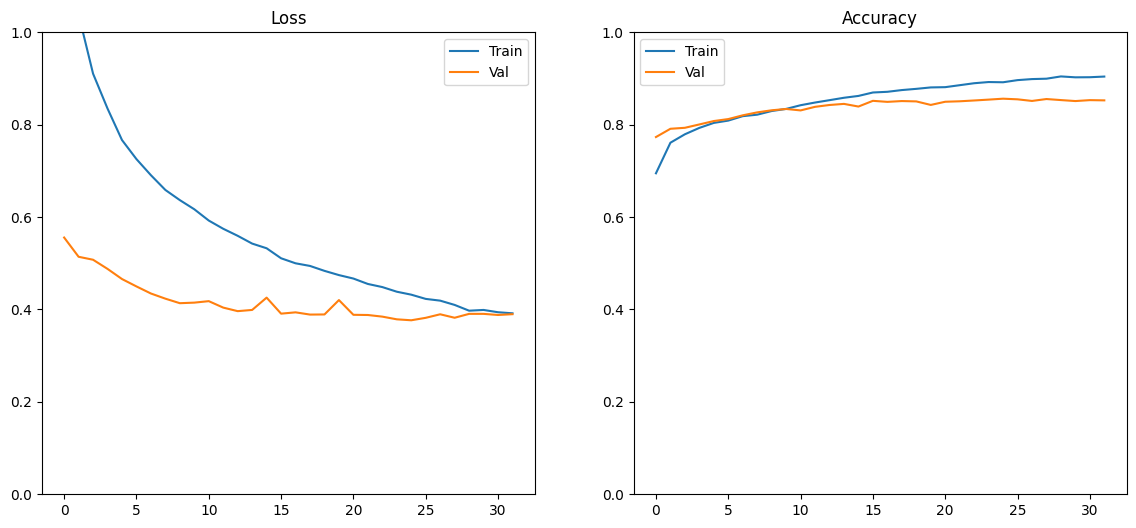


 Final evaluation on the test set...
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step

--- FINAL REPORT (Threshold: 0.35) ---
              precision    recall  f1-score   support

     Healthy       0.85      0.81      0.83     16391
       Tumor       0.82      0.86      0.84     16377

    accuracy                           0.84     32768
   macro avg       0.84      0.84      0.84     32768
weighted avg       0.84      0.84      0.84     32768



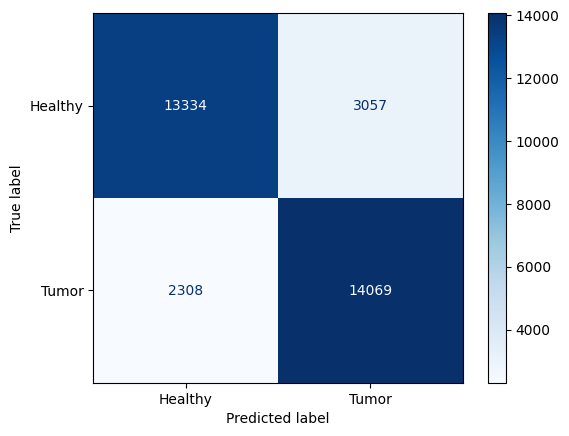

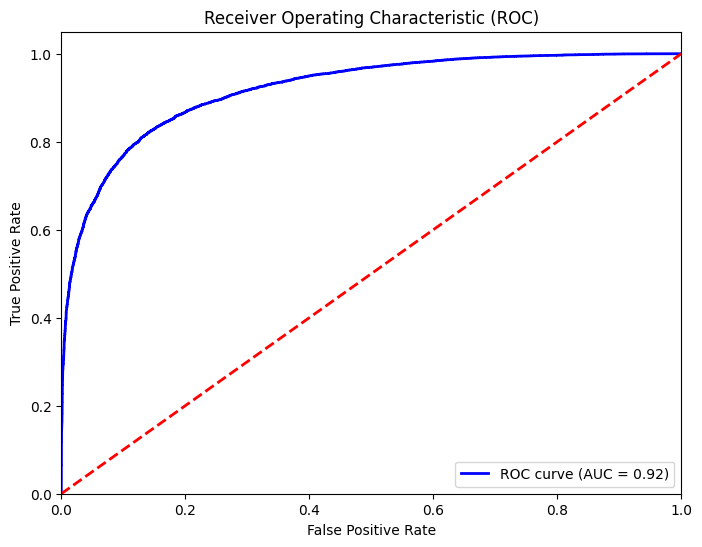

In [ ]:
from google.colab import drive
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tqdm import tqdm

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# LOCAL COPY OF FILES
for f in ['train_x','train_y','valid_x','valid_y','test_x','test_y']:
    src = f"/content/drive/MyDrive/PCam/camelyonpatch_level_2_split_{f}.h5"
    dst = f"/content/camelyonpatch_level_2_split_{f}.h5"
    if os.path.exists(src) and not os.path.exists(dst):
        !cp "$src" /content/
print("Files ready on the local disk")

np.random.seed(42)
tf.random.set_seed(42)

# LOADING DATA (80k)
def load_to_ram(x_path, y_path, num_samples=80000):
    with h5py.File(y_path, 'r') as fy:
        y_all = fy['y'][:].reshape(-1)
        idx_0 = np.where(y_all == 0)[0]
        idx_1 = np.where(y_all == 1)[0]
        n = num_samples // 2
        selected_indices = np.concatenate([np.random.choice(idx_0, n, replace=False),
                                            np.random.choice(idx_1, n, replace=False)])
        np.random.shuffle(selected_indices)
        y_final = y_all[selected_indices].reshape(-1, 1)

    x_final = np.empty((num_samples, 96, 96, 3), dtype='uint8')
    with h5py.File(x_path, 'r') as fx:
        ds = fx['x']
        for i, idx in enumerate(tqdm(selected_indices, desc="Loading")):
            x_final[i] = ds[idx]
    return x_final, y_final

X_train, Y_train = load_to_ram('/content/camelyonpatch_level_2_split_train_x.h5',
                                    '/content/camelyonpatch_level_2_split_train_y.h5', 80000)
with h5py.File('/content/camelyonpatch_level_2_split_valid_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_valid_y.h5','r') as fy:
    X_val, Y_val = fx['x'][:8000], fy['y'][:8000].reshape(-1,1)



# Model (Color Augmentation + DenseNet)

tf.keras.mixed_precision.set_global_policy('mixed_float16')

def build_advanced_model():
    inputs = layers.Input(shape=(96, 96, 3))

    #  DATA AUGMENTATION
    x = layers.CenterCrop(64, 64)(inputs)
    x = layers.RandomFlip("horizontal_and_vertical")(x)
    x = layers.RandomRotation(0.5)(x)
    x = layers.RandomBrightness(0.15)(x)
    x = layers.RandomContrast(0.15)(x)

    x = tf.keras.applications.densenet.preprocess_input(x)

    # PRE-TRAINED MODEL
    base_model = tf.keras.applications.DenseNet121(
        weights='imagenet', include_top=False, input_shape=(64, 64, 3)
    )
    base_model.trainable = True

    x = base_model(x)


    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    return models.Model(inputs, outputs)

model = build_advanced_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)


# TRAINING PHASE

class_weights = {0: 1.0, 1: 3.5}

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).shuffle(2000).batch(128).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(128).prefetch(tf.data.AUTOTUNE)

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
]

print("\n Training with Color Augmentation and Class Weight 3.0...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_list
)


# Final save
model.save('/content/drive/MyDrive/PCam/DenseNet121_Medical_Final_Model.keras')
print(" Model saved successfully to Google Drive")


# FINAL EVALUATION

# Loss
plt.figure(figsize=(14,6))
plt.subplot(1,2,1); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title("Loss"); plt.ylim(0, 1.0); plt.legend()

# Accuracy
plt.subplot(1,2,2); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title("Accuracy"); plt.ylim(0, 1.0); plt.legend()
plt.show()


print("\n Final evaluation on the test set...")
with h5py.File('/content/camelyonpatch_level_2_split_test_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_test_y.h5','r') as fy:
    X_test, Y_test = fx['x'][:], fy['y'][:].reshape(-1,1)

y_pred_prob = model.predict(X_test, batch_size=256)

threshold = 0.35
y_pred_class = (y_pred_prob > threshold).astype(int)

print(f"\n--- FINAL REPORT (Threshold: {threshold}) ---")
print(classification_report(Y_test, y_pred_class, target_names=["Healthy","Tumor"]))

cm = confusion_matrix(Y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Tumor"])
disp.plot(cmap='Blues')
plt.show()

# ROC Curve plotting
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()